In [1]:
import pandas as pd
import numpy as np

In [2]:
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import scipy.stats as stats

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [5]:
df = pd.read_excel(fpath + '\\4.0_database_variables.xlsx')

In [6]:
df = df.rename(columns={'location(ita=0,uk=1,usa=2)': 'location', 'weekday(1=free days)': 'weekday'})

In [7]:
# UK
df_uk = df[df['location'] == 1]
df_uk = df_uk[['midpoint_h', 'weekday']]
df_uk = df_uk.groupby('weekday').describe()

# ITA
df_ita = df[df['location'] == 0]
df_ita = df_ita[['midpoint_h', 'weekday']]
df_ita = df_ita.groupby('weekday').describe()

In [8]:
df_uk

midpoint_h                                                        \
             count       mean       std        min        25%        50%   
weekday                                                                    
0            172.0  26.454457  0.793070  24.675000  25.921875  26.570833   
1             66.0  27.332765  1.167309  23.591667  26.888542  27.525000   

                             
             75%        max  
weekday                      
0        26.9250  29.808333  
1        28.0125  29.675000

In [9]:
df_ita

midpoint_h                                                    \
             count       mean       std    min        25%        50%   
weekday                                                                
0            241.0  26.709595  0.864688  23.95  26.012500  26.695833   
1            100.0  27.237167  1.885401  11.25  26.711458  27.479167   

                             
               75%      max  
weekday                      
0        27.358333  28.6875  
1        28.004167  29.6250

In [10]:
model_1 = ols('midpoint_h ~ C(location) * C(weekday)', data=df).fit()

In [11]:
anova_results = sm.stats.anova_lm(model_1, typ=3)

In [12]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                               sum_sq     df              F    PR(>F)
Intercept               171929.999699    1.0  135892.449643  0.000000
C(location)                  6.533501    1.0       5.164040  0.023428
C(weekday)                  19.670929    1.0      15.547785  0.000090
C(location):C(weekday)       3.503251    1.0       2.768949  0.096654
Residual                   727.485229  575.0            NaN       NaN


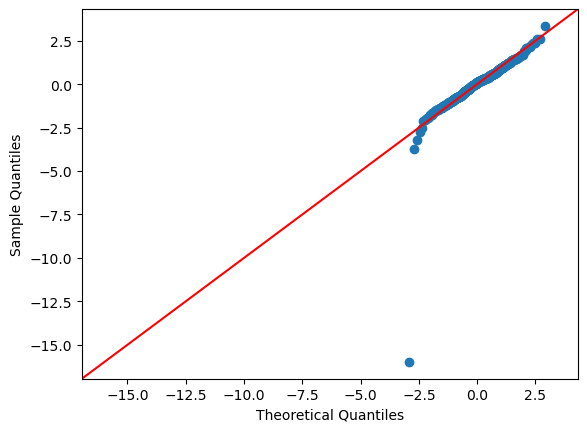

In [13]:
#  generate QQ-plot from standardized residuals (outliers can be easily detected from standardized residuals than normal residuals)
fig = sm.qqplot(model_1.resid, line='45')
plt.show()

In [14]:
#detecting outliers
outliers = model_1.get_influence()
outliers_summary = outliers.summary_frame()
outliers_summary = outliers_summary[outliers_summary['cooks_d'] > 4 / len(df)]
outliers_summary = outliers_summary.sort_values('cooks_d', ascending=False)
print(outliers_summary)

     dfb_Intercept  dfb_C(location)[T.1]  dfb_C(weekday)[T.1]  \
65   -1.219896e-13          1.230077e-15        -1.501384e+00   
113  -9.895243e-14          8.980038e-15         1.507099e-14   
205  -9.869056e-14         -6.219635e-14        -3.423752e-14   
198  -9.842423e-14         -5.260017e-14         6.412621e-14   
220  -1.475377e-13         -6.595422e-14         6.158661e-14   
45   -1.474228e-13          3.369469e-14         2.993772e-14   
263  -9.828066e-14         -9.910083e-15        -9.147525e-15   
187  -9.827674e-14         -6.540394e-14         4.989360e-15   
215  -1.975042e-13          1.759123e-01        -9.358520e-14   
333  -1.964931e-13         -7.231850e-14         1.662609e-14   
16   -1.473581e-13          3.714695e-14         2.410591e-14   
93   -9.837133e-14          3.967690e-15         1.808298e-01   
127  -9.832104e-14         -4.957077e-14         1.687529e-01   
219  -1.472912e-13         -6.584403e-14         6.148371e-14   
106  -9.818838e-14       

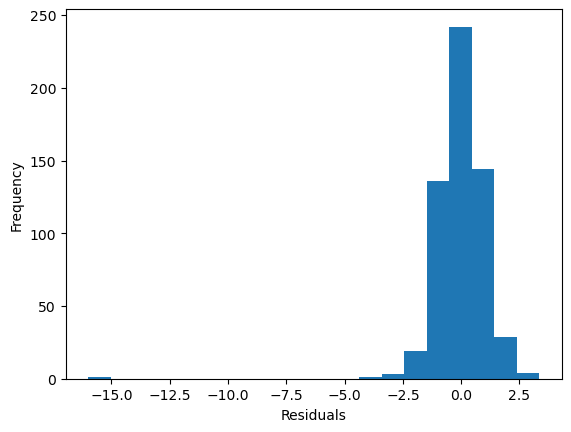

In [15]:
#frequency vs residuals
plt.hist(model_1.resid, bins=20)
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [16]:
# Shapiro-Wilk test 
# Null hypothesis: data is drawn from normal distribution
w, pvalue = stats.shapiro(model_1.resid) 
print(w, pvalue)

0.7660492454767855 6.911636786869559e-28


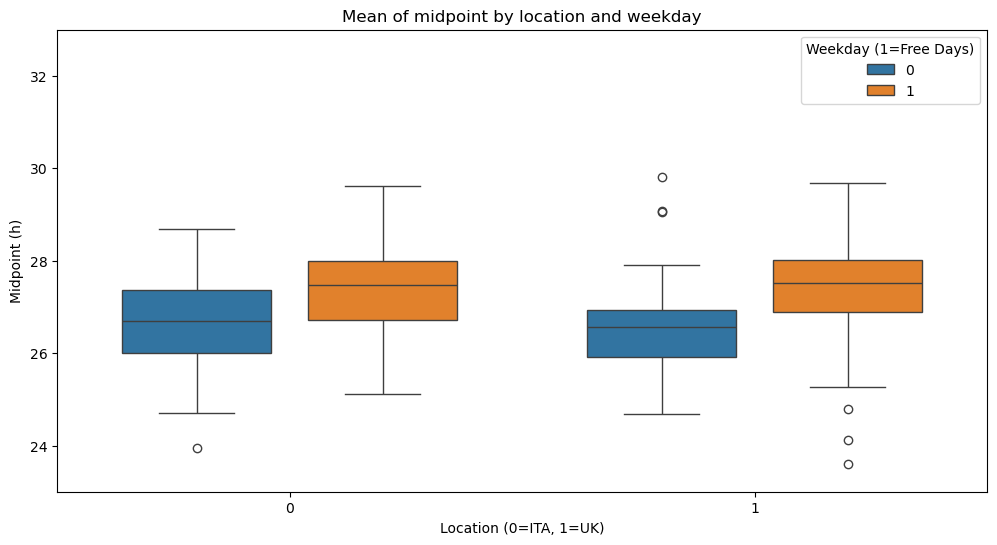

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='midpoint_h', hue='weekday', data=df, gap=0.2)
plt.title('Mean of midpoint by location and weekday')
plt.xlabel('Location (0=ITA, 1=UK)')
plt.ylim(23, 33)
plt.ylabel('Midpoint (h)')
plt.legend(title='Weekday (1=Free Days)')
plt.show()

------------------------------------------------------------------------------------

In [19]:
df = df.rename(columns={'sleep_duration(h)': 'sleep_duration'})

In [23]:
model_2 = ols('sleep_duration ~ C(location) * C(weekday)', data=df).fit()

In [24]:
anova_results = sm.stats.anova_lm(model_2, typ=3)

In [25]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                              sum_sq     df             F    PR(>F)
Intercept               18826.342337    1.0  10194.141565  0.000000
C(location)                 1.198127    1.0      0.648765  0.420888
C(weekday)                  4.181861    1.0      2.264406  0.132926
C(location):C(weekday)      1.310334    1.0      0.709524  0.399952
Residual                 1061.898815  575.0           NaN       NaN


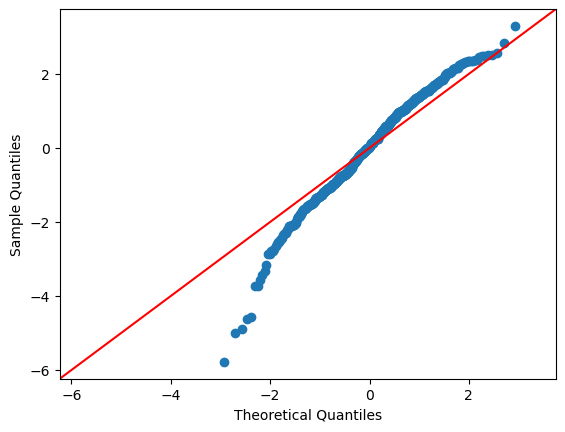

In [26]:
#  generate QQ-plot from standardized residuals (outliers can be easily detected from standardized residuals than normal residuals)
fig = sm.qqplot(model_2.resid, line='45')
plt.show()

In [27]:
#detecting outliers
outliers = model_2.get_influence()
outliers_summary = outliers.summary_frame()
outliers_summary = outliers_summary[outliers_summary['cooks_d'] > 4 / len(df)]
outliers_summary = outliers_summary.sort_values('cooks_d', ascending=False)
print(outliers_summary)

     dfb_Intercept  dfb_C(location)[T.1]  dfb_C(weekday)[T.1]  \
127  -2.060487e-14         -1.495931e-14        -3.668431e-01   
155  -2.052076e-14         -1.034601e-15        -3.163731e-01   
65   -2.050842e-14         -1.550967e-15        -3.082887e-01   
499  -2.041027e-14         -4.939343e-15        -2.345357e-01   
540  -4.079663e-14         -2.879596e-15        -2.239294e-01   
13   -6.144671e-14         -2.007936e-01        -1.074514e-14   
235  -2.033373e-14         -1.558260e-14        -8.430553e-15   
395  -2.033254e-14         -1.711935e-14         2.580630e-15   
396  -2.032902e-14         -1.711639e-14         2.580183e-15   
122  -2.191899e-01          1.414522e-01         1.186980e-01   
459  -4.070425e-14         -2.462636e-15         1.771503e-01   
31   -2.034921e-14         -2.667474e-15        -1.737829e-01   
403  -2.034921e-14         -1.682561e-14        -1.737829e-01   
263  -2.032159e-14         -6.762089e-15         2.751190e-15   
424  -6.095426e-14       

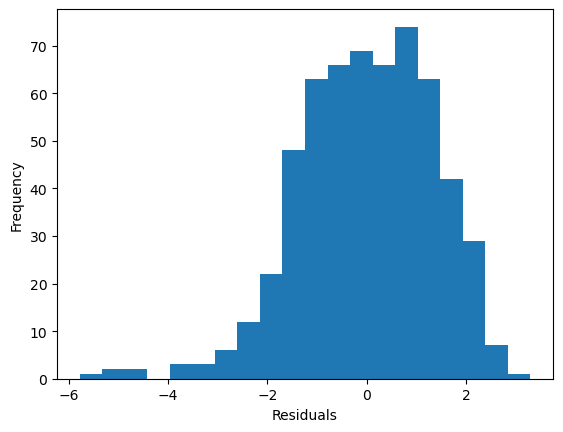

In [28]:
#frequency vs residuals
plt.hist(model_2.resid, bins=20)
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [29]:
# Shapiro-Wilk test 
# Null hypothesis: data is drawn from normal distribution
w, pvalue = stats.shapiro(model_2.resid) 
print(w, pvalue)

0.9803422375817856 5.017552345921912e-07


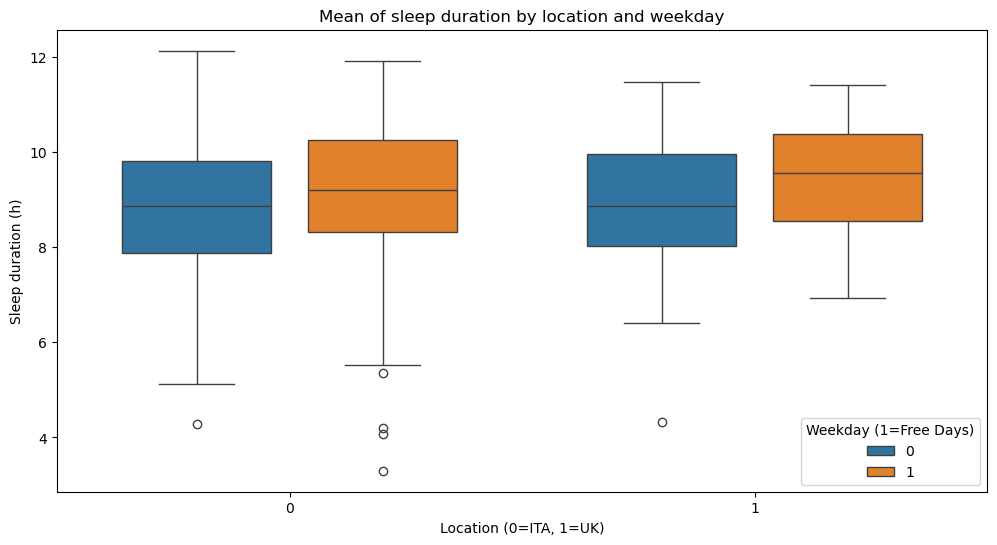

In [33]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='sleep_duration', hue='weekday', data=df, gap=0.2)
plt.title('Mean of sleep duration by location and weekday')
plt.xlabel('Location (0=ITA, 1=UK)')
plt.ylim()
plt.ylabel('Sleep duration (h)')
plt.legend(title='Weekday (1=Free Days)')
plt.show()

------------------------------------------------------

In [54]:
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})

In [55]:
model_3 = ols('phase ~ C(location) * C(weekday)', data=df).fit()

In [56]:
anova_results = sm.stats.anova_lm(model_3, typ=3)

In [57]:
print("ANOVA Results:")
print(anova_results)

ANOVA Results:
                             sum_sq     df          F        PR(>F)
Intercept                122.814668    1.0  52.791647  1.214053e-12
C(location)              102.540606    1.0  44.076881  7.316473e-11
C(weekday)                36.844796    1.0  15.837664  7.784491e-05
C(location):C(weekday)     2.445862    1.0   1.051349  3.056278e-01
Residual                1337.681957  575.0        NaN           NaN


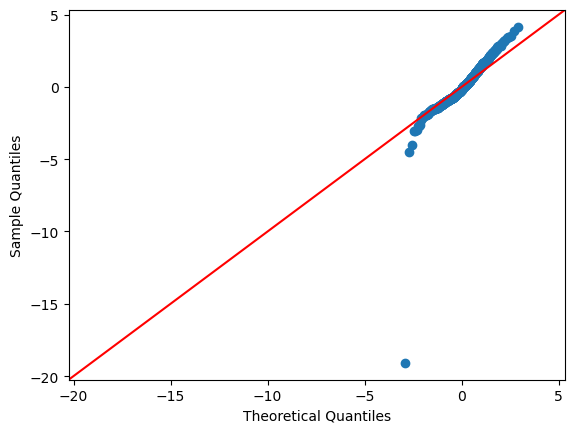

In [58]:
#  generate QQ-plot from standardized residuals (outliers can be easily detected from standardized residuals than normal residuals)
fig = sm.qqplot(model_3.resid, line='45')
plt.show()

In [59]:
#detecting outliers
outliers = model_3.get_influence()
outliers_summary = outliers.summary_frame()
outliers_summary = outliers_summary[outliers_summary['cooks_d'] > 4 / len(df)]
outliers_summary = outliers_summary.sort_values('cooks_d', ascending=False)
print(outliers_summary)

     dfb_Intercept  dfb_C(location)[T.1]  dfb_C(weekday)[T.1]  \
65    2.652329e-15          0.000000e+00        -1.247426e+00   
113   5.680153e-15         -4.398762e-15        -1.845585e-15   
220   4.542293e-15         -4.396991e-15        -4.304631e-15   
155   2.275290e-15          0.000000e+00        -2.508193e-01   
486   4.536045e-15         -4.390943e-15        -1.842305e-15   
534   4.533844e-15         -4.388812e-15        -1.841411e-15   
506   4.533200e-15         -4.388189e-15        -1.841149e-15   
235   3.398887e-15         -5.849176e-15        -3.067668e-15   
487   2.268190e-15         -1.463756e-15         1.923165e-01   
333   4.528940e-15         -5.845420e-15        -1.839419e-15   
16    4.528704e-15         -4.383837e-15        -2.452431e-15   
533   4.527420e-15         -4.382594e-15        -1.838802e-15   
514   3.400000e-15         -1.462773e-15         1.772971e-01   
215   6.818248e-15          1.601049e-01        -6.153814e-16   
480   4.526981e-15       

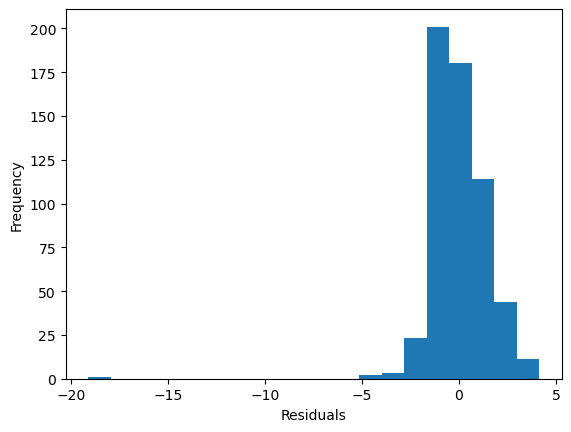

In [60]:
#frequency vs residuals
plt.hist(model_3.resid, bins=20)
plt.xlabel("Residuals")
plt.ylabel('Frequency')
plt.show()

In [61]:
# Shapiro-Wilk test 
# Null hypothesis: data is drawn from normal distribution
w, pvalue = stats.shapiro(model_3.resid) 
print(w, pvalue)

0.8239553846725531 1.0396914618911964e-24


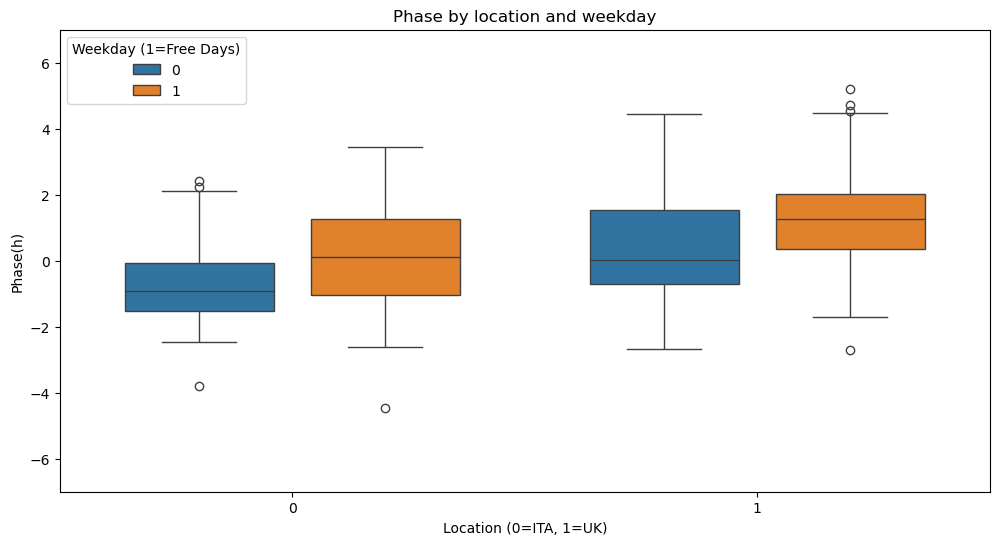

In [64]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='location', y='phase', hue='weekday', data=df, gap=0.2)
plt.title('Phase by location and weekday')
plt.xlabel('Location (0=ITA, 1=UK)')
plt.ylim(-7,7)
plt.ylabel('Phase(h)')
plt.legend(title='Weekday (1=Free Days)')
plt.show()

----------------------------------------------------------------------------------

In [41]:
# Assicurarsi che la colonna "date" sia in formato datetime
df['date'] = pd.to_datetime(df['date'])

In [42]:
# Aggiungere una colonna con la settimana dell'anno
df['week'] = df['date'].dt.isocalendar().week

In [43]:
# Filtrare solo le posizioni UK (1) e ITA (0)
data_filtered = df[df['location'].isin([0, 1])]

In [44]:
# Calcolare le medie del midpoint_h per giorni lavorativi e giorni liberi per ogni settimana e location
weekly_means = data_filtered.groupby(['location', 'week', 'weekday'])['midpoint_h'].mean().unstack()

In [45]:
# Calcolare il jet lag come differenza tra giorni liberi (1) e giorni lavorativi (0)
weekly_means['jet_lag'] = weekly_means[1] - weekly_means[0]

In [46]:
# Visualizzare i risultati del calcolo del jet lag
print(weekly_means[['jet_lag']].dropna())

weekday         jet_lag
location week          
0        3     0.862292
         4     1.184583
         7     0.586458
         8     0.794167
         11    1.427083
         12    0.197917
         13    2.215417
         16    1.663542
         17    0.399583
         22   -0.475833
         25    1.466250
         26    0.415417
         29    0.202500
         30    0.802778
         32   -0.329167
         33    0.028869
         34    0.824479
         35    1.811667
         37    2.750000
         38    1.161161
         39    0.970000
         41   -0.396875
         42    0.798125
         43    0.790625
         46    0.257500
         47   -3.300417
         48    1.125000
         50    0.301042
         51    0.801875
         52    0.573843
1        1    -0.319792
         2    -0.722083
         5     0.964583
         6     1.453125
         9     0.587500
         10    1.874583
         14   -1.013889
         15    1.822500
         18    1.732523
         19    0

In [47]:
# Creare un dataframe per il confronto
comparison_data = weekly_means.reset_index()

In [50]:
# Adattare un modello OLS per il confronto tra UK e ITA
model_jetlag = ols('jet_lag ~ C(location)', data=comparison_data).fit()
anova_jetlag = sm.stats.anova_lm(model_jetlag, typ=3)

In [51]:
# Visualizzare i risultati dell'ANOVA per il jet lag
print(anova_jetlag)

                sum_sq    df          F    PR(>F)
Intercept    13.213443   1.0  11.544420  0.001357
C(location)   0.071002   1.0   0.062034  0.804351
Residual     56.084125  49.0        NaN       NaN
